In [74]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  )
import matplotlib.pyplot as plt
import seaborn as sns


In [75]:
!pip install catboost -q
from catboost import CatBoostClassifier


In [76]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier


In [77]:
df=pd.read_csv("/content/sample_data/fertilizer_recommendation.csv")
df.head()


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


In [78]:
df.isnull().sum()

,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Nitrogen_Level,0
Phosphorus_Level,0
Potassium_Level,0
Temperature,0
Humidity,0


In [79]:
X = df.drop("Recommended_Fertilizer", axis=1)
Y = df["Recommended_Fertilizer"]
#print(X.iloc[:,:10])
#print(Y.iloc[:10])

In [80]:
# CatBoost , LightGBM and XGBoost can handle categorical columns directly.

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()  # select all 'object' type columns and replace it with 'categorical'

for col in cat_features:
    X[col] = X[col].astype("category")

print("Categorical features:", cat_features)


Categorical features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region']


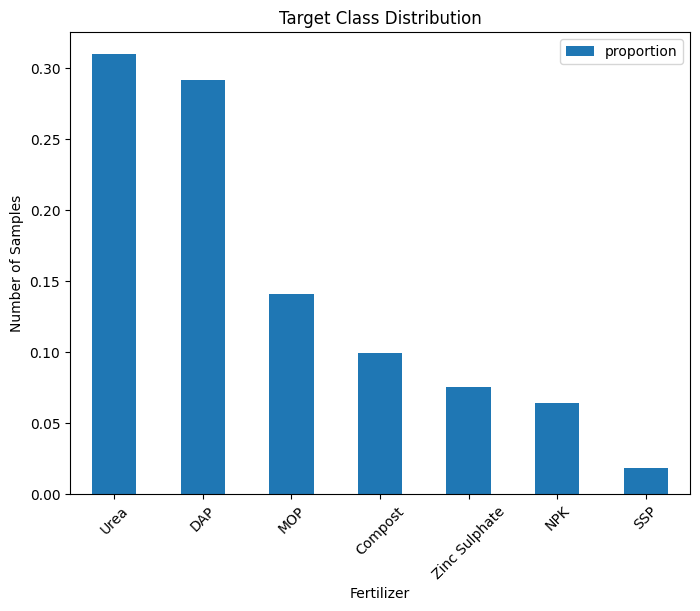

In [81]:
#  diplay data balancing
df["Recommended_Fertilizer"].value_counts(normalize=True).plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Target Class Distribution")
plt.xlabel("Fertilizer")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [83]:
X_train_cat,X_test_cat,y_train_cat,y_test_cat=train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)

In [84]:
# The target is imbalanced, so use simple built-in class balancing.
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.01,
    depth=3,
    random_seed=42,
    auto_class_weights="Balanced",
    verbose=0
)

start_time = time.time()

cat_model.fit(X_train_cat,y_train_cat,cat_features=cat_features)

cat_time = time.time() - start_time

y_predict_CAT = cat_model.predict(X_test_cat).ravel()

cat_accuracy = accuracy_score(y_test_cat, y_predict_CAT)
cat_f1 = f1_score(y_test_cat, y_predict_CAT, average="macro")
cat_precision = precision_score( y_test_cat, y_predict_CAT, average="macro", zero_division=0)
cat_recall = recall_score(y_test_cat, y_predict_CAT, average="macro", zero_division=0)

print("Time     CatGB:", cat_time)
print("Accuracy CatGB:", cat_accuracy)
print("Macro F1 CatGB:", cat_f1)
print("Precision   CatGB:", cat_precision)
print("Recall      CatGB:", cat_recall)

Time     CatGB: 47.579394578933716
Accuracy CatGB: 0.8655
Macro F1 CatGB: 0.7933916353529386
Precision   CatGB: 0.8656201130675693
Recall      CatGB: 0.8376761350165135


In [85]:
# Encod target variable
encoder=LabelEncoder()
Y=encoder.fit_transform(Y)
X=OrdinalEncoder().fit_transform(X)

In [86]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)

In [87]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

start_time = time.time()

rf_model.fit(X_train, y_train)

rf_time = time.time() - start_time

# Prediction
y_predict_RF = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, y_predict_RF)

rf_f1 = f1_score(
    y_test,
    y_predict_RF,
    average="macro"
)

rf_precision = precision_score(
    y_test,
    y_predict_RF,
    average="macro",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_predict_RF,
    average="macro",
    zero_division=0
)

print("Time Random Forest:", rf_time)
print("Accuracy Random Forest:", rf_accuracy)
print("Macro F1 Random Forest:", rf_f1)
print("Precision Random Forest:", rf_precision)
print("Recall Random Forest:", rf_recall)

Time Random Forest: 5.852298736572266
Accuracy Random Forest: 0.868
Macro F1 Random Forest: 0.7926507172233975
Precision Random Forest: 0.863234917791568
Recall Random Forest: 0.8347243629403412


In [88]:
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    random_state=42,
    min_child_samples=1,
    class_weight="balanced",
    verbosity=-1
)

start_time = time.time()

lgb_model.fit(X_train,y_train)

lgb_time = time.time() - start_time

y_predict_LGB = lgb_model.predict(X_test)

lgb_accuracy = accuracy_score(y_test, y_predict_LGB)
lgb_f1 = f1_score(y_test, y_predict_LGB, average="macro")
lgb_precision = precision_score( y_test, y_predict_LGB, average="macro", zero_division=0)
lgb_recall = recall_score(y_test, y_predict_LGB, average="macro", zero_division=0)

print("Time     LightGB:", lgb_time)
print("Accuracy LightGB:", lgb_accuracy)
print("Macro F1 LightGB:", lgb_f1)
print("Precision   LightGB:", lgb_precision)
print("Recall      LightGB:", lgb_recall)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Time     LightGB: 9.8348069190979
Accuracy LightGB: 0.8715
Macro F1 LightGB: 0.7635468139433609
Precision   LightGB: 0.7766909877856653
Recall      LightGB: 0.7932544752082583


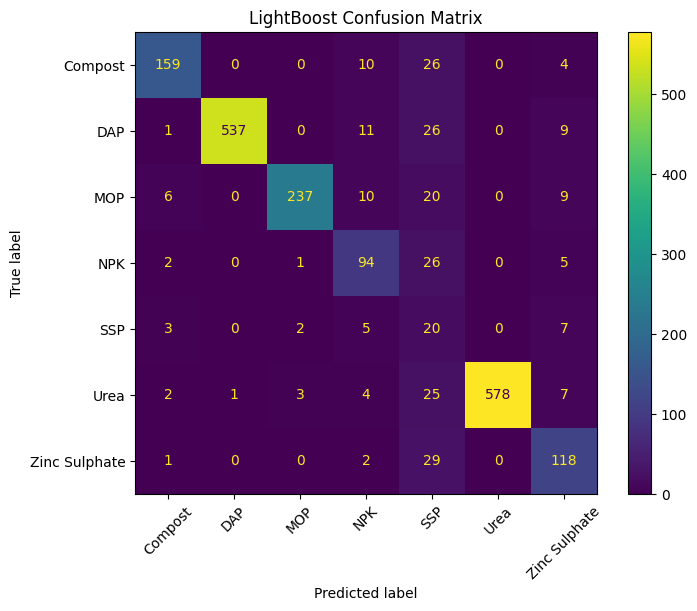

In [89]:
cm = confusion_matrix(y_test, y_predict_LGB)
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("LightBoost Confusion Matrix")
plt.show()

In [90]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=1,
    random_state=42,
    class_weight="balanced",
    eval_metric="mlogloss",
    n_jobs=-1
)

start_time = time.time()

xgb_model.fit(X_train, y_train)

xgb_time = time.time() - start_time

y_predict_XGB = xgb_model.predict(X_test)

# Evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_predict_XGB)

xgb_precision = precision_score( y_test, y_predict_XGB, average="macro", zero_division=0)

xgb_recall = recall_score(y_test, y_predict_XGB, average="macro", zero_division=0)

xgb_f1 = f1_score( y_test, y_predict_XGB, average="macro", zero_division=0 )

print("Time        XGBoost:", xgb_time)
print("Accuracy    XGBoost:", xgb_accuracy)
print("Precision   XGBoost:", xgb_precision)
print("Recall      XGBoost:", xgb_recall)
print("Macro F1    XGBoost:", xgb_f1)

# print("\nClassification Report:")
# print(classification_report(Y, y_predict_XGB,zero_division=0))

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [09:18:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Time        XGBoost: 4.860843181610107
Accuracy    XGBoost: 0.872
Precision   XGBoost: 0.7564388681337226
Recall      XGBoost: 0.7405279358204749
Macro F1    XGBoost: 0.7455872253608712


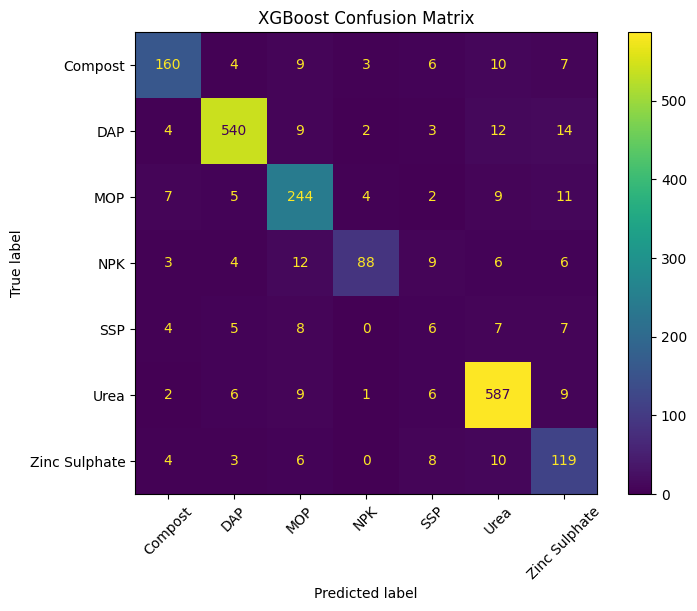

In [91]:
cm = confusion_matrix(y_test, y_predict_XGB)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [92]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "CatBoost",
        "LightGBM",
        "XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        cat_accuracy,
        lgb_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        rf_precision,
        cat_precision,
        lgb_precision,
        xgb_precision
    ],

    "Recall": [
        rf_recall,
        cat_recall,
        lgb_recall,
        xgb_recall
    ],

    "Macro F1": [
        rf_f1,
        cat_f1,
        lgb_f1,
        xgb_f1
    ],

    "Training Time (sec)": [
        rf_time,
        cat_time,
        lgb_time,
        xgb_time
    ]
})

results = results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,Macro F1,Training Time (sec)
0,CatBoost,0.8655,0.865620,0.837676,0.793392,47.579395
1,Random Forest,0.8680,0.863235,0.834724,0.792651,5.852299
2,LightGBM,0.8715,0.776691,0.793254,0.763547,9.834807
3,XGBoost,0.8720,0.756439,0.740528,0.745587,4.860843


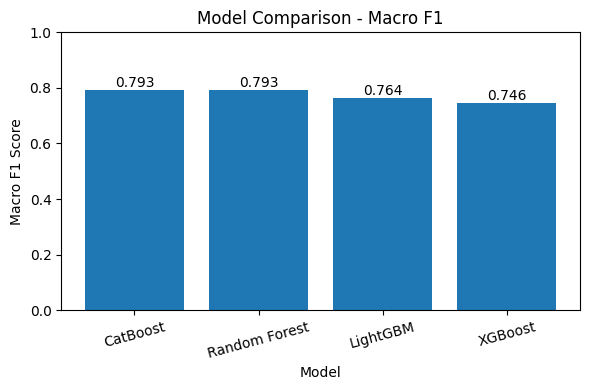

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

bars = plt.bar(
    results["Model"],
    results["Macro F1"]
)

plt.title("Model Comparison - Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=15)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [94]:
winner = results.loc[
    results["Macro F1"].idxmax()
]

print(f"🏆 Winner: {winner['Model']}")
print(f"Macro F1: {winner['Macro F1']:.4f}")

🏆 Winner: CatBoost
Macro F1: 0.7934


In [95]:
import joblib

joblib.dump(
    cat_model,
    "catboost_fertilizer_model.pkl"
)

['catboost_fertilizer_model.pkl']